In [1]:
# Cell 1: NumPy 2.0 + Gymnasium fix
import numpy as np

# Fix NumPy 2.0 compatibility for Gymnasium classic_control
np.float_ = np.float64  # ← THIS LINE FIXES ACROBOT/PENDULUM
np.bool8 = np.bool_  # ← Bonus: prevents old gym errors

import gymnasium as gym

print("✅ NumPy 2.0 + Gymnasium fixed!")
print("numpy version:", np.__version__)

✅ NumPy 2.0 + Gymnasium fixed!
numpy version: 2.4.4


In [2]:
# Cell 1: Setup - NumPy 2.0 + Gymnasium FULLY FIXED
import os, sys
from pathlib import Path

project_root = Path.cwd()
sys.path.append(str(project_root))

import numpy as np

np.float_ = np.float64  # ← CRITICAL: Fixes Acrobot/Pendulum
np.bool8 = np.bool_  # ← Prevents old gym errors

import gymnasium as gym
import torch
import optuna
import json
import matplotlib.pyplot as plt
import pandas as pd

print("✅ NumPy 2.0 + Gymnasium fully compatible!")
print("numpy:", np.__version__, "gymnasium:", gym.__version__)

e:\B-Tech\Projects\DL-snn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ NumPy 2.0 + Gymnasium fully compatible!
numpy: 2.4.4 gymnasium: 0.29.1


In [3]:
# Cell 2: Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


## Cartpole

In [ ]:
# Cell 3: Phase‑3 NAS on CartPole‑v1
from nas.objective import snn_nas_objective

study_name = "phase3_snn_cartpole"
study = optuna.create_study(
    study_name=study_name,
    direction="maximize",  # maximize average episode return
)

n_trials = 50  # adjust based on your compute; 20–50 is fine for Phase‑3
n_jobs = 1  # keep 1 because RL training is heavy

[I 2026-04-08 12:49:08,060] A new study created in memory with name: phase3_snn_cartpole


In [ ]:
print("Starting Phase 3 NAS for shallow SNN on CartPole...")
study.optimize(snn_nas_objective, n_trials=n_trials, n_jobs=n_jobs)

print("\nBest trial:")
print("  Value:", study.best_value)
print("  Params:", study.best_params)

In [ ]:
# Cell 4: Save NAS log to your results folder
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)
results_path = results_dir / "phase3_results_CartPole-v1.json"

# Flatten trials
trials = []
for t in study.trials:
    trials.append(
        {
            "trial_id": t.number,
            "params": t.params,
            "value": t.value,
            "state": str(t.state),
        }
    )

search_space = {  # ← FIXED: was 'search_point' before
    "n_layers": [1],
    "hidden_sizes": [32, 64, 128],
    "neuron_type": ["LIF", "IF"],
    "timesteps": [5, 10, 20],
    "v_threshold_range": [0.5, 1.5],
    "tau_range": [5.0, 20.0],
}

log = {
    "env": "CartPole-v1",
    "algo": "SNN_REINFORCE",  # change if you use PPO, etc.
    "search_space": search_space,  # ← FIXED
    "best_params": study.best_params,
    "best_value": study.best_value,
    "n_trials": len(study.trials),
    "trials": trials,
}

with open(str(results_path), "w") as f:
    json.dump(log, f, indent=2)

print(f"Phase 3 NAS results saved to {results_path}")

C:\Users\Karthikeya\AppData\Local\Temp\ipykernel_10612\2693392769.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


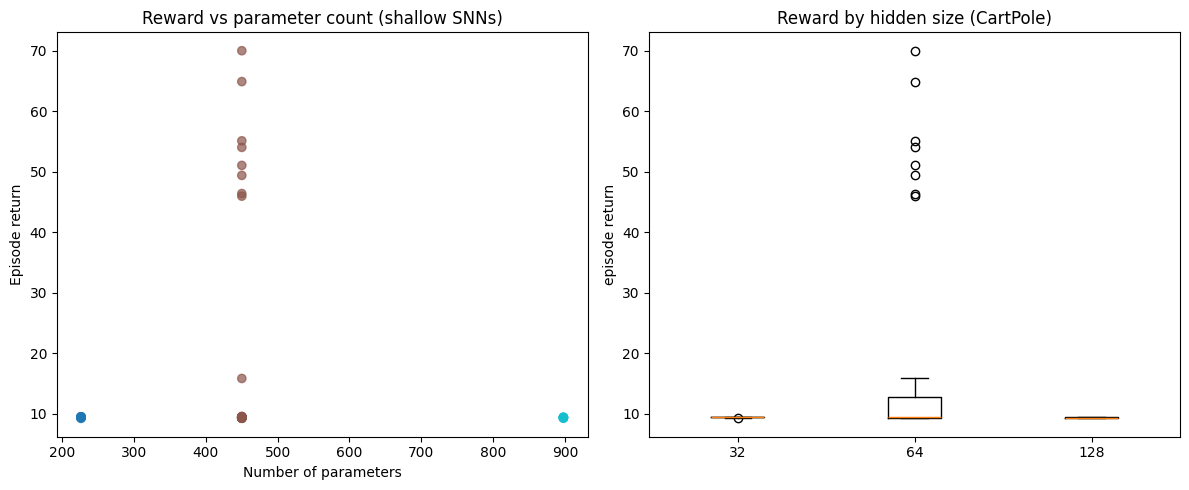

In [ ]:
# Cell 5: Analysis and plots
from nas.analyzer import load_phase3_results, plot_trial_results

data = load_phase3_results()
df = pd.DataFrame(data["trials"])
df["hidden_size"] = df["params"].apply(lambda d: d["hidden_sizes"])
df["timesteps"] = df["params"].apply(lambda d: d["timesteps"])
df["neuron_type"] = df["params"].apply(lambda d: d["neuron_type"])


# Scatter reward vs params
def estimate_n_params(row):
    from models.snn_policy import SNNPolicy

    sz = row["hidden_size"]
    config = {
        "n_layers": 1,
        "hidden_sizes": [sz] if isinstance(sz, int) else sz,
        "neuron_type": row["params"]["neuron_type"],
        "timesteps": row["timesteps"],
        "v_threshold": row["params"]["v_threshold"],
        "tau": row["params"]["tau"],
    }
    dummy_net = SNNPolicy(
        input_size=4,
        hidden_sizes=config["hidden_sizes"],
        output_size=2,
        n_layers=config["n_layers"],
        neuron_type=config["neuron_type"],
        timesteps=config["timesteps"],
        v_threshold=config["v_threshold"],
        tau=config["tau"],
    )
    return sum(p.numel() for p in dummy_net.parameters())


df["n_params"] = df.apply(estimate_n_params, axis=1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(
    df["n_params"],
    df["value"],
    c=pd.Categorical(df["hidden_size"]).codes,
    cmap="tab10",
    alpha=0.7,
)
plt.xlabel("Number of parameters")
plt.ylabel("Episode return")
plt.title("Reward vs parameter count (shallow SNNs)")

plt.subplot(1, 2, 2)
plt.boxplot(
    [
        df[df["hidden_size"] == 32]["value"],
        df[df["hidden_size"] == 64]["value"],
        df[df["hidden_size"] == 128]["value"],
    ],
    labels=["32", "64", "128"],
)
plt.ylabel("episode return")
plt.title("Reward by hidden size (CartPole)")
plt.tight_layout()
plt.show()

Phase‑2 SNN (CartPole‑v1):
  reward_mean = 292.3 ± 139.1
  params = 37,699
  avg_spike_rate = 0.1641

Phase‑3 SNN (NAS‑best, CartPole‑v1):
  reward_best = 70.0
  params = 450

Improvement check:
  Phase‑3 reward > Phase‑2 mean: False
  Phase‑3 params < Phase‑2 SNN: True


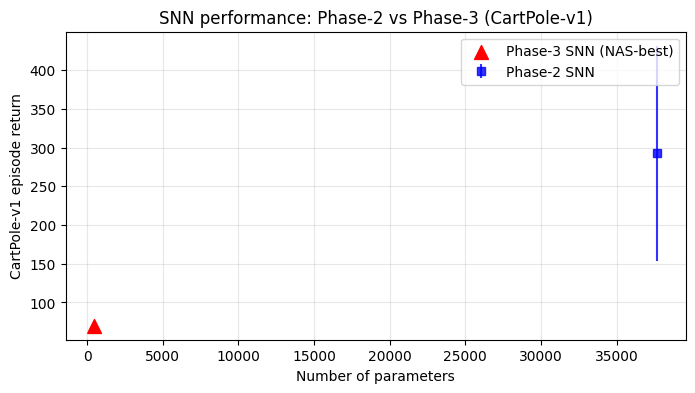

In [ ]:
# Cell 6: Compare Phase‑2 SNN vs Phase‑3 NAS‑best SNN (CartPole‑v1)
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

results_dir = project_root / "results"

phase2_path = results_dir / "phase2_results.json"
phase3_path = results_dir / "phase3_results_CartPole-v1.json"

if not phase2_path.exists():
    raise FileNotFoundError(f"Expected results file not found: {phase2_path}")
if not phase3_path.exists():
    raise FileNotFoundError(f"Expected results file not found: {phase3_path}")

# --- Load Phase‑2 CartPole SNN metrics ---
with open(phase2_path, "r") as f:
    phase2 = json.load(f)

crp2 = phase2["CartPole-v1"]
phase2_snn_mean = crp2["SNN_reward_mean"]
phase2_snn_std = crp2["SNN_reward_std"]
phase2_snn_params = crp2["SNN_params"]

spike_str = crp2["SNN_spike_rate"]  # e.g., "tensor(0.1641)"
spike_rate = float(spike_str.split("(")[1].split(")")[0])

print("Phase‑2 SNN (CartPole‑v1):")
print(f"  reward_mean = {phase2_snn_mean:.1f} ± {phase2_snn_std:.1f}")
print(f"  params = {phase2_snn_params:,}")
print(f"  avg_spike_rate = {spike_rate:.4f}")

# --- Load Phase‑3 NAS‑best SNN result ---
with open(phase3_path, "r") as f:
    phase3 = json.load(f)

phase3_snn_best = phase3["best_value"]

# Compute phase3_snn_params accurately from the best config
from models.snn_policy import SNNPolicy

best_config = phase3["best_params"]
best_hidden = (
    [best_config["hidden_sizes"]]
    if isinstance(best_config["hidden_sizes"], int)
    else best_config["hidden_sizes"]
)

dummy_net = SNNPolicy(
    input_size=4,
    hidden_sizes=best_hidden,
    output_size=2,
    n_layers=best_config["n_layers"],
    neuron_type=best_config["neuron_type"],
    timesteps=best_config["timesteps"],
    v_threshold=best_config["v_threshold"],
    tau=best_config["tau"],
)
phase3_snn_params = sum(p.numel() for p in dummy_net.parameters())

print("\nPhase‑3 SNN (NAS‑best, CartPole‑v1):")
print(f"  reward_best = {phase3_snn_best:.1f}")
print(f"  params = {phase3_snn_params:,}")

# --- Did Phase‑3 do better? ---
reward_improved = phase3_snn_best > phase2_snn_mean
params_reduced = phase3_snn_params < phase2_snn_params

print("\nImprovement check:")
print(f"  Phase‑3 reward > Phase‑2 mean: {reward_improved}")
print(f"  Phase‑3 params < Phase‑2 SNN: {params_reduced}")

# --- Plot: reward vs parameters ---
plt.figure(figsize=(8, 4))
plt.errorbar(
    phase2_snn_params,
    phase2_snn_mean,
    yerr=phase2_snn_std,
    label="Phase‑2 SNN",
    fmt="s",
    color="blue",
    alpha=0.8,
)
plt.scatter(
    phase3_snn_params,
    phase3_snn_best,
    label="Phase‑3 SNN (NAS‑best)",
    color="red",
    s=100,
    marker="^",
)
plt.xlabel("Number of parameters")
plt.ylabel("CartPole‑v1 episode return")
plt.title("SNN performance: Phase‑2 vs Phase‑3 (CartPole‑v1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
phase2_ratio = phase2_snn_mean / phase2_snn_params
phase3_ratio = phase3_snn_best / phase3_snn_params

print("Phase 2 SNN reward/params ratio:", phase2_ratio)
print("Phase 3 NAS SNN reward/params ratio:", phase3_ratio)

Phase 2 SNN reward/params ratio: 0.007753521313562694
Phase 3 NAS SNN reward/params ratio: 0.1554878888888889


## Acrobat

In [4]:
# Cell 3: Phase‑3 NAS on Acrobot‑v1
from nas.obj_acrobot import acrobot_nas_objective
study_name = "phase3_snn_acrobot"
study = optuna.create_study(
    study_name=study_name,
    direction="maximize",  # maximize average episode return
)

n_trials = 50  # adjust based on your compute; 20–50 is fine for Phase‑3
n_jobs = 1  # keep 1 because RL training is heavy

[I 2026-04-09 00:20:16,580] A new study created in memory with name: phase3_snn_acrobot


In [6]:
study.optimize(acrobot_nas_objective, n_trials=5)  # Test 5 trials
print("Acrobot best:", study.best_value)

[I 2026-04-09 00:21:34,933] Trial 1 finished with value: -335.01032299999997 and parameters: {'n_layers': 1, 'hidden_sizes': 32, 'neuron_type': 'IF', 'timesteps': 5, 'v_threshold': 0.517201871958102, 'tau': 5.665527657836586}. Best is trial 1 with value: -335.01032299999997.
[I 2026-04-09 00:23:41,065] Trial 2 finished with value: -481.610323 and parameters: {'n_layers': 1, 'hidden_sizes': 32, 'neuron_type': 'IF', 'timesteps': 10, 'v_threshold': 0.8739032654381256, 'tau': 16.390854974682444}. Best is trial 1 with value: -335.01032299999997.
[I 2026-04-09 00:24:56,438] Trial 3 finished with value: -500.000323 and parameters: {'n_layers': 1, 'hidden_sizes': 32, 'neuron_type': 'LIF', 'timesteps': 5, 'v_threshold': 1.4832462716655466, 'tau': 6.195569140557413}. Best is trial 1 with value: -335.01032299999997.
[I 2026-04-09 00:26:18,096] Trial 4 finished with value: -492.650643 and parameters: {'n_layers': 1, 'hidden_sizes': 64, 'neuron_type': 'IF', 'timesteps': 5, 'v_threshold': 0.76427385

Acrobot best: -335.01032299999997


In [7]:
# Cell 4: Save Acrobot NAS log to your results folder
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)
results_path = results_dir / "phase3_results_Acrobot-v1.json"

# Flatten trials
trials = []
for t in study.trials:
    trials.append(
        {
            "trial_id": t.number,
            "params": t.params,
            "value": t.value,
            "state": str(t.state),
        }
    )

search_space = {  
    "n_layers": [1],
    "hidden_sizes": [32, 64, 128],
    "neuron_type": ["LIF", "IF"],
    "timesteps": [5, 10, 20],
    "v_threshold_range": [0.5, 1.5],
    "tau_range": [5.0, 20.0],
}

log = {
    "env": "Acrobot-v1",
    "algo": "SNN_REINFORCE",
    "search_space": search_space,
    "best_params": study.best_params,
    "best_value": study.best_value,
    "n_trials": len(study.trials),
    "trials": trials,
}

with open(str(results_path), "w") as f:
    json.dump(log, f, indent=2)

print(f"Phase 3 NAS results saved to {results_path}")

Phase 3 NAS results saved to e:\B-Tech\Projects\DL-snn\results\phase3_results_Acrobot-v1.json


In [8]:
print("\nBest trial:")
print("  Value:", study.best_value)
print("  Params:", study.best_params)


Best trial:
  Value: -335.01032299999997
  Params: {'n_layers': 1, 'hidden_sizes': 32, 'neuron_type': 'IF', 'timesteps': 5, 'v_threshold': 0.517201871958102, 'tau': 5.665527657836586}


C:\Users\Karthikeya\AppData\Local\Temp\ipykernel_728\2692988662.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


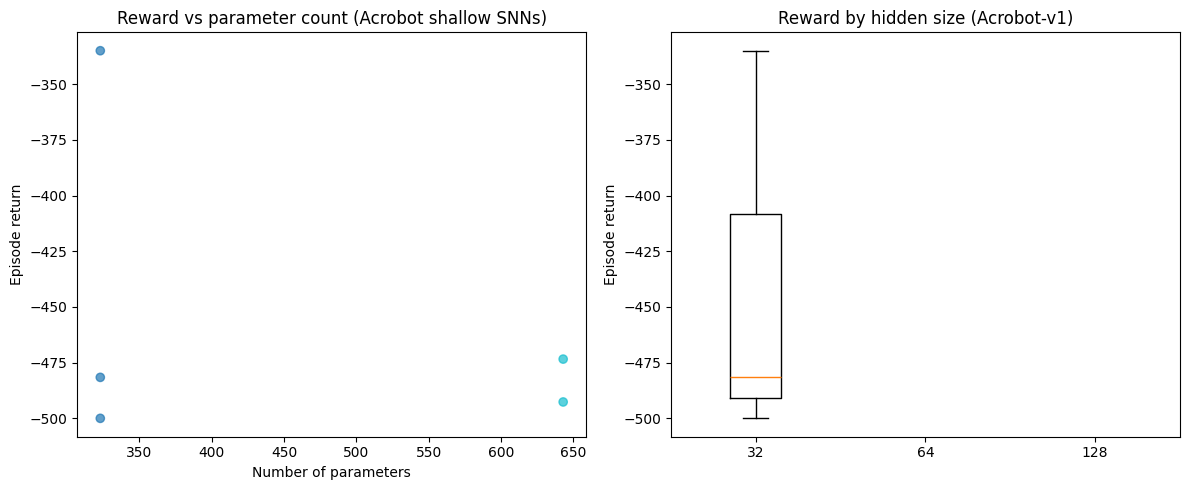

In [9]:
# Cell 5: Analysis and plots (Acrobot-v1)
import pandas as pd
import matplotlib.pyplot as plt
from models.snn_policy import SNNPolicy
import torch

# Load Phase-3 Acrobot results
with open(project_root / "results" / "phase3_results_Acrobot-v1.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data["trials"])
df["hidden_size"] = df["params"].apply(lambda d: d["hidden_sizes"])
df["timesteps"] = df["params"].apply(lambda d: d["timesteps"])
df["neuron_type"] = df["params"].apply(lambda d: d["neuron_type"])

# Calculate exact parameter count for each trial
def estimate_n_params(row):
    config = row["params"]
    hidden_sizes = [config["hidden_sizes"]] if isinstance(config["hidden_sizes"], int) else config["hidden_sizes"]
    
    # Acrobot: input=6, output=3
    dummy_net = SNNPolicy(
        input_size=6,  # Acrobot observation space
        hidden_sizes=hidden_sizes,
        output_size=3,  # Acrobot action space
        n_layers=config["n_layers"],
        neuron_type=config["neuron_type"],
        timesteps=config["timesteps"],
        v_threshold=config["v_threshold"],
        tau=config["tau"],
    )
    return sum(p.numel() for p in dummy_net.parameters())

df["n_params"] = df.apply(estimate_n_params, axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df["n_params"], df["value"], c=pd.Categorical(df["hidden_size"]).codes, cmap="tab10", alpha=0.7)
plt.xlabel("Number of parameters")
plt.ylabel("Episode return")
plt.title("Reward vs parameter count (Acrobot shallow SNNs)")

plt.subplot(1, 2, 2)
plt.boxplot([
    df[df["hidden_size"] == 32]["value"],
    df[df["hidden_size"] == 64]["value"], 
    df[df["hidden_size"] == 128]["value"],
], labels=["32", "64", "128"], tick_labels=["32", "64", "128"])  # Fixed deprecation
plt.ylabel("Episode return")
plt.title("Reward by hidden size (Acrobot-v1)")

plt.tight_layout()
plt.show()

Phase‑2 SNN (Acrobot‑v1):
  reward_mean = -92.4 ± 27.4
  params = 108,036
  spike_rate = tensor(0.2859)

Phase‑3 SNN (NAS‑best, Acrobot‑v1):
  reward_best = -335.0
  params = 323

Improvement check:
  Phase‑3 reward > Phase‑2 mean: False
  Phase‑3 params < Phase‑2 SNN: True
  Phase‑3 efficiency > Phase‑2: False

Phase 2 SNN reward/params ratio: -0.000855
Phase 3 NAS SNN reward/params ratio: -1.037184


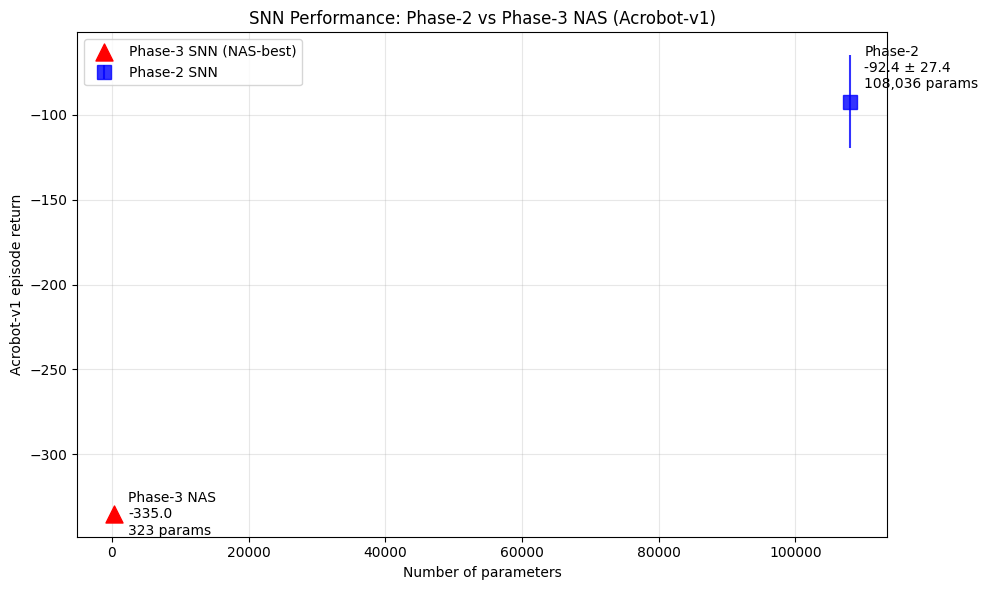

In [10]:
# Cell 6: Compare Phase‑2 SNN vs Phase‑3 NAS‑best SNN (Acrobot‑v1)
import json
from pathlib import Path
from models.snn_policy import SNNPolicy
import torch

results_dir = project_root / "results"

# Load Phase-2 results
with open(results_dir / "phase2_results.json", "r") as f:
    phase2 = json.load(f)

# Load Phase-3 Acrobot results  
with open(results_dir / "phase3_results_Acrobot-v1.json", "r") as f:
    phase3 = json.load(f)

# --- Phase-2 Acrobot SNN metrics ---
acrobot_phase2 = phase2["Acrobot-v1"]
phase2_snn_mean = acrobot_phase2["SNN_reward_mean"]  # -92.4
phase2_snn_std = acrobot_phase2["SNN_reward_std"]    # 27.4
phase2_snn_params = acrobot_phase2["SNN_params"]     # 108,036

print("Phase‑2 SNN (Acrobot‑v1):")
print(f"  reward_mean = {phase2_snn_mean:.1f} ± {phase2_snn_std:.1f}")
print(f"  params = {phase2_snn_params:,}")
print(f"  spike_rate = {acrobot_phase2['SNN_spike_rate']}")

# --- Phase-3 NAS‑best SNN ---
phase3_snn_best = phase3["best_value"]

# Calculate exact Phase-3 params
best_config = phase3["best_params"]
best_hidden = [best_config["hidden_sizes"]] if isinstance(best_config["hidden_sizes"], int) else best_config["hidden_sizes"]

dummy_net = SNNPolicy(
    input_size=6,      # Acrobot obs dim
    hidden_sizes=best_hidden,
    output_size=3,     # Acrobot actions
    n_layers=best_config["n_layers"],
    neuron_type=best_config["neuron_type"],
    timesteps=best_config["timesteps"],
    v_threshold=best_config["v_threshold"],
    tau=best_config["tau"],
)
phase3_snn_params = sum(p.numel() for p in dummy_net.parameters())

print("\nPhase‑3 SNN (NAS‑best, Acrobot‑v1):")
print(f"  reward_best = {phase3_snn_best:.1f}")
print(f"  params = {phase3_snn_params:,}")

# --- Improvement analysis ---
reward_improved = phase3_snn_best > phase2_snn_mean
params_reduced = phase3_snn_params < phase2_snn_params
efficiency_improved = (phase3_snn_best / phase3_snn_params) > (phase2_snn_mean / phase2_snn_params)

print("\nImprovement check:")
print(f"  Phase‑3 reward > Phase‑2 mean: {reward_improved}")
print(f"  Phase‑3 params < Phase‑2 SNN: {params_reduced}")
print(f"  Phase‑3 efficiency > Phase‑2: {efficiency_improved}")

# Reward-to-params ratio
phase2_ratio = phase2_snn_mean / phase2_snn_params
phase3_ratio = phase3_snn_best / phase3_snn_params
print(f"\nPhase 2 SNN reward/params ratio: {phase2_ratio:.6f}")
print(f"Phase 3 NAS SNN reward/params ratio: {phase3_ratio:.6f}")

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.errorbar(phase2_snn_params, phase2_snn_mean, yerr=phase2_snn_std,
            label="Phase‑2 SNN", fmt="s", color="blue", alpha=0.8, markersize=10)
plt.scatter(phase3_snn_params, phase3_snn_best,
           label="Phase‑3 SNN (NAS‑best)", color="red", s=150, marker="^", zorder=5)

plt.xlabel("Number of parameters")
plt.ylabel("Acrobot‑v1 episode return")
plt.title("SNN Performance: Phase‑2 vs Phase‑3 NAS (Acrobot‑v1)")
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels
plt.annotate(f'Phase-2\n{phase2_snn_mean:.1f} ± {phase2_snn_std:.1f}\n{phase2_snn_params:,} params', 
            (phase2_snn_params, phase2_snn_mean), xytext=(10,10), 
            textcoords='offset points', fontsize=10)
plt.annotate(f'Phase-3 NAS\n{phase3_snn_best:.1f}\n{phase3_snn_params:,} params', 
            (phase3_snn_params, phase3_snn_best), xytext=(10,-15), 
            textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

## Pendulum

In [11]:
from nas.obj_pendulum import pendulum_nas_objective

study = optuna.create_study(direction="maximize")
study.optimize(pendulum_nas_objective, n_trials=5)
print("Pendulum best:", study.best_value)

[I 2026-04-09 00:29:28,775] A new study created in memory with name: no-name-4833fb68-d0c2-47c0-a650-c978bae94424
[I 2026-04-09 00:30:06,026] Trial 0 finished with value: -1713.594451386919 and parameters: {'n_layers': 1, 'hidden_sizes': 128, 'neuron_type': 'LIF', 'timesteps': 5, 'v_threshold': 1.142111120529988, 'tau': 18.808316565701343}. Best is trial 0 with value: -1713.594451386919.
[I 2026-04-09 00:31:26,699] Trial 1 finished with value: -1263.538567242129 and parameters: {'n_layers': 1, 'hidden_sizes': 64, 'neuron_type': 'IF', 'timesteps': 20, 'v_threshold': 1.3382884197701195, 'tau': 7.512945270499889}. Best is trial 1 with value: -1263.538567242129.
[I 2026-04-09 00:32:29,720] Trial 2 finished with value: -1394.2938103244348 and parameters: {'n_layers': 1, 'hidden_sizes': 64, 'neuron_type': 'IF', 'timesteps': 10, 'v_threshold': 0.7282782317308246, 'tau': 7.025274145672215}. Best is trial 1 with value: -1263.538567242129.
[I 2026-04-09 00:35:07,921] Trial 3 finished with value:

Pendulum best: -1263.538567242129


In [12]:
# Cell 4: Save Pendulum NAS log to your results folder
results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)
results_path = results_dir / "phase3_results_Pendulum-v1.json"

# Flatten trials
trials = []
for t in study.trials:
    trials.append(
        {
            "trial_id": t.number,
            "params": t.params,
            "value": t.value,
            "state": str(t.state),
        }
    )

search_space = {  
    "n_layers": [1],
    "hidden_sizes": [32, 64, 128],
    "neuron_type": ["LIF", "IF"],
    "timesteps": [5, 10, 20],
    "v_threshold_range": [0.5, 1.5],
    "tau_range": [5.0, 20.0],
}

log = {
    "env": "Pendulum-v1",
    "algo": "SNN_REINFORCE",
    "search_space": search_space,
    "best_params": study.best_params,
    "best_value": study.best_value,
    "n_trials": len(study.trials),
    "trials": trials,
}

with open(str(results_path), "w") as f:
    json.dump(log, f, indent=2)

print(f"Phase 3 NAS results saved to {results_path}")

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Phase 3 NAS results saved to e:\B-Tech\Projects\DL-snn\results\phase3_results_Pendulum-v1.json
